In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from sklearn.model_selection import train_test_split

# Loading in the data

In [2]:
X_loaded = np.load("gplvm_latent_indianpines_5.npy")  # Shape: (21025, Q)
X_out_reshaped = X_loaded.reshape(145, 145, -1)  # Shape: (145, 145, Q)

print(X_out_reshaped.shape)  # e.g., (145, 145, 5)

(145, 145, 5)


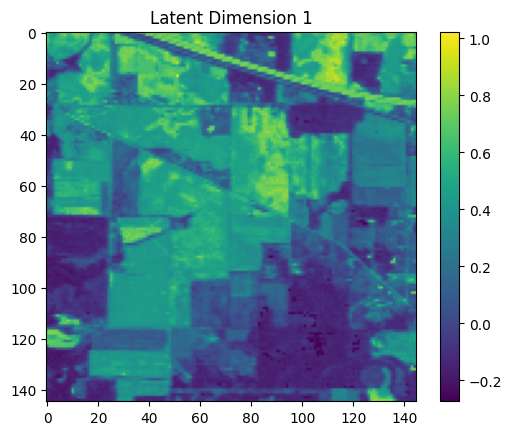

In [3]:
# Show 1st latent dimension
plt.imshow(X_out_reshaped[:, :, 0], cmap="viridis")
plt.title("Latent Dimension 1")
plt.colorbar()
plt.show()

In [4]:
# Reading Labels

# Loading all pixel labels
gt_label_data = loadmat('Indian_pines_gt.mat')['indian_pines_gt']
print(gt_label_data.shape)
labels_flat = gt_label_data.flatten()  # shape: (21025,)

(145, 145)


In [5]:

Q = X_out_reshaped.shape[-1] # Latent dim
H, W = X_out_reshaped.shape[:2] # Pixel Height and Width
known_labels = (labels_flat > 0)  # Exclude 0s (unlabeled) # e.g., values from 1 to 16
labels_raw = labels_flat[known_labels] # e.g., values from 1 to 16
num_classes = len(np.unique(labels_raw))

In [6]:
Q, H, W, num_classes

(5, 145, 145, 16)

In [7]:
# --------------------
# Dataset Definition
# --------------------
class HyperspectralDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data.astype("float32")
        self.labels = labels.astype("int64")

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        x = self.data[idx]   # (Q,)
        y = self.labels[idx] # scalar
        return x, y

# Setting up CNN Model

In [ ]:
# --------------------
# CNN Model
# --------------------
import torch.nn as nn
import torch.nn.functional as F

class LightSegCNN2D(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(LightSegCNN2D, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.25)
        )
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Conv2d(32, num_classes, kernel_size=1)  # logits per pixel
        )

    def forward(self, x):
        # x: (B, Q) → reshape to (B, Q, 1, 1) for convs
        x = x.unsqueeze(-1).unsqueeze(-1)  # (B, Q, 1, 1)
        x = self.encoder(x)
        x = self.decoder(x)  # (B, num_classes, 1, 1)
        return x.view(x.size(0), -1)  # (B, num_classes)


In [9]:
# --------------------
# Preprocess Function
# --------------------
def preprocess_latent_and_labels(X_latent, label_mask):
    # X_latent: (H, W, Q), label_mask: (H, W)
    H, W, Q = X_latent.shape

    # Flatten spatial dims
    X = X_latent.reshape(-1, Q)   # (H*W, Q)
    Y = label_mask.flatten()      # (H*W,)

    # Remove background pixels (label 0)
    mask = Y > 0
    X = X[mask]
    Y = Y[mask] - 1   # shift to 0..C-1

    return X, Y

In [10]:
# --------------------
# Example Usage
# --------------------
# Example: after GPLVM, you have latent features
H, W, Q # 145, 145, 5  # example
num_classes # 16

# Example dummy data
#X_latent = X_out_reshaped
#label_mask = gt_label_data  # 0=background

X_latent = X_out_reshaped
label_mask = gt_label_data  # 0=background
#print(label_mask.shape)

X, Y = preprocess_latent_and_labels(X_latent, label_mask)
print(X.shape, " ", Y.shape)
# Train-test split at image level
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)

train_dataset = HyperspectralDataset(X_train, Y_train)
val_dataset   = HyperspectralDataset(X_val, Y_val)

from torch.utils.data import DataLoader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)


(10249, 5)   (10249,)


In [11]:
np.unique(Y)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15],
      dtype=uint8)

In [12]:
# Initialize the NN
LightSeg_model = LightSegCNN2D(in_channels=Q, num_classes=num_classes)
print(LightSeg_model)

LightSegCNN2D(
  (encoder): Sequential(
    (0): Conv2d(5, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
  )
  (decoder): Sequential(
    (0): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.25, inplace=False)
    (4): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1))
  )
)


In [13]:
x, y = next(iter(train_loader))

print(x.shape, " ", y.shape)

torch.Size([64, 5])   torch.Size([64])


In [14]:
X_train, y_train = next(iter(train_loader))
print(X_train.shape)
print(LightSeg_model.forward(X_train).shape)
y_train.shape

torch.Size([64, 5])
torch.Size([64, 16])


torch.Size([64])

In [15]:
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import cohen_kappa_score, f1_score, confusion_matrix

# ---------- Metric Functions ----------
def pixel_accuracy(outputs, targets):
    preds = torch.argmax(outputs, dim=1)  # (B, H, W)
    correct = (preds == targets).sum().item()
    total = torch.numel(targets)
    return correct / total


def mean_iou(outputs, targets, num_classes):
    preds = torch.argmax(outputs, dim=1).cpu().numpy()
    targets = targets.cpu().numpy()
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (targets == cls)
        intersection = (pred_inds & target_inds).sum()
        union = (pred_inds | target_inds).sum()
        if union == 0:
            ious.append(float('nan'))  # ignore if class not present
        else:
            ious.append(intersection / union)
    return np.nanmean(ious)


def mean_f1(outputs, targets, num_classes):
    preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()
    return f1_score(targets, preds, labels=list(range(num_classes)), average="macro",
                   zero_division=0   # instead of warning, set F1=0 when undefined
                   )


def kappa(outputs, targets):
    preds = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
    targets = targets.cpu().numpy().flatten()
    return cohen_kappa_score(targets, preds)

# Train the network

In [16]:
from IPython.display import clear_output

# Train your model with batch normalisation and dropout, and monitor the training progress with the validation
# loss and accuracy. Keep also checkpointing and early stopping.

# Set up loss and optimiser
loss = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(LightSeg_model.parameters(), lr=0.001)

n_epochs = 40

# Variable to track the highest running accuracy
top_val_acc = 0

# Variable to track the lowest running loss value
min_val_loss = 1e5

# Lists to store running losses and accuracies of both datasets
train_losses, val_losses = [], []
train_acc, val_acc = [], []

# Loops over epochs: copy the training loop from before and make the necessary changes!
# Loops over epochs like before
# Training loop
for epoch in range(n_epochs):

    LightSeg_model.train()
    # Running training loss and accuracies for the epoch
    tot_train_loss = 0
    train_correct = 0

    # Training iteration for one epoch
    for X_batch, y_batch in train_loader:
        #print(X_batch.unsqueeze(0).shape)
        model_pred = LightSeg_model.forward(X_batch) # (B, num_classes)
        #print("outputs: ", outputs.shape)
        #print(targets.shape)
        batch_loss = loss(model_pred, y_batch)
        tot_train_loss += batch_loss.item() * X_batch.shape[0]

        optimiser.zero_grad()
        batch_loss.backward()
        optimiser.step()

        predicted_class = torch.argmax(model_pred,dim=1)
        matches = torch.eq(predicted_class, y_batch)
        train_correct += torch.sum(matches.float())


    # Running training loss and accuracies for the epoch
    tot_val_loss = 0
    val_correct = 0
    val_iou, val_f1, val_kappa = 0, 0, 0

    # Validation step
    with torch.no_grad():
        LightSeg_model.eval()
        for X, y in test_loader:
            model_pred = LightSeg_model.forward(X)
            batch_loss = loss(model_pred, y)
            tot_val_loss += batch_loss.item() * X.shape[0]

            predicted_class = torch.argmax(model_pred,dim=1)
            matches = torch.eq(predicted_class, y)
            val_correct += torch.sum(matches.float())

            val_iou += mean_iou(model_pred, y, num_classes) * X.shape[0]
            val_f1  += mean_f1(model_pred, y, num_classes) * X.shape[0]
            val_kappa += kappa(model_pred, y) * X.shape[0]
        #LightSeg_model.train()

    # Work out average loss for the epoch using running losses
    train_loss = tot_train_loss / len(train_loader.dataset)
    val_loss = tot_val_loss / len(test_loader.dataset)
    train_accuracy = train_correct / len(train_loader.dataset)
    val_accuracy = val_correct / len(test_loader.dataset)

    val_iou /= len(test_loader.dataset)
    val_f1 /= len(test_loader.dataset)
    val_kappa /= len(test_loader.dataset)

    # Store these loss and accuracy values
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_acc.append(train_accuracy)
    val_acc.append(val_accuracy)

    # Printout and plotting
    clear_output(wait=True)
    print(f"Epoch: {epoch+1}/{n_epochs},\
    Training Loss: {train_loss:.3f},\
    Training Accuracy: {train_accuracy:.3f},\
    Test Loss: {val_loss:.3f},\
    Test Accuracy: {val_accuracy:.3f}")

    print(f"Validation -> mIoU: {val_iou:.4f}, "
      f"F1: {val_f1:.4f}, Kappa: {val_kappa:.4f}")

    # Track the top accuracy for the printout
    if val_accuracy > top_val_acc:
        top_val_acc = val_accuracy


    # Checkpoint if validation loss decreases
    if val_loss < min_val_loss:
        torch.save(LightSeg_model,'LightSeg_model_IndianPines5')
        min_val_loss = val_loss
        count = 0
    else:
        count = count + 1

    print(f"Best validation loss is {min_val_loss}")


    # Early stopping: Terminate the loop if counter reaches 10
    if count == 10:
        break



Epoch: 40/40,    Training Loss: 1.083,    Training Accuracy: 0.604,    Test Loss: 0.894,    Test Accuracy: 0.680
Validation -> mIoU: 0.5044, F1: 0.4556, Kappa: 0.6239
Best validation loss is 0.8878044701785576


# Visualization and Evaluation

Best Test accuracy is: 0.6800000071525574 with latent variable: 5


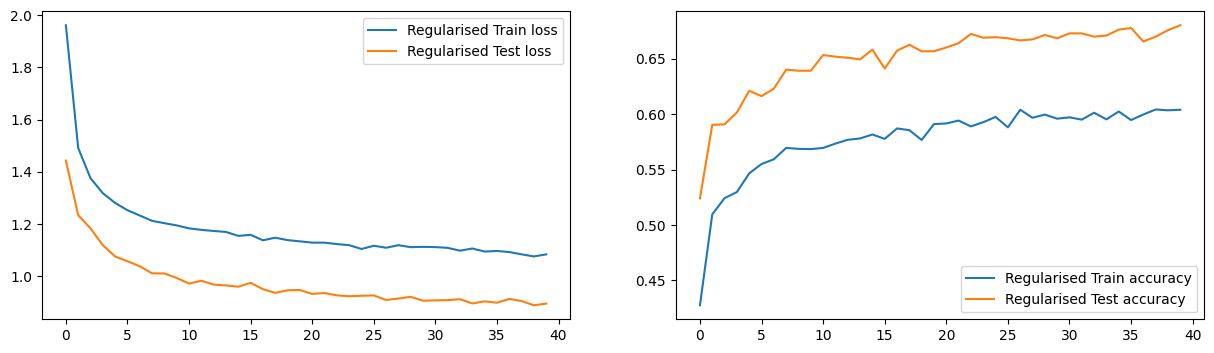

In [17]:
print(f"Best Test accuracy is: {top_val_acc} with latent variable: {Q}")

plt.figure(figsize=(15,4))
plt.subplot(121)
plt.plot(train_losses,label='Regularised Train loss')
plt.plot(val_losses,label='Regularised Test loss')
plt.legend()
plt.subplot(122)
plt.plot(train_acc,label='Regularised Train accuracy')
plt.plot(val_acc,label='Regularised Test accuracy')
plt.legend()
plt.show()